# CS301 Term Project: Subset Sum

This notebook contains the Python implementation and experiments for the Subset Sum project.

Sections included in this notebook:

- Section 4: Random Instance Generator
- Section 5: Algorithm Implementations and Initial Testing
- Section 6: Experimental Analysis of Performance

In [1]:
import random
import math
import itertools
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Section 4: Sample Generation

In this section, we create a random instance generator for the Subset Sum problem.

Each instance contains:

- A list of positive integers `S`
- A target value `T`

The target is created using a percentage of the total sum of the list.

In [2]:
def generate_subset_sum_instance(n, min_value=1, max_value=100, target_ratio=0.5, seed=None):
    """
    This function creates one random Subset Sum problem.
    It returns a list of numbers and a target value.
    """

    # A seed lets us repeat the same random example if needed
    if seed is not None:
        random.seed(seed)

    # Basic input checks so the function does not run with invalid values
    if n <= 0:
        raise ValueError("n must be greater than 0.")

    if min_value <= 0:
        raise ValueError("min_value must be positive.")

    if max_value < min_value:
        raise ValueError("max_value must be greater than or equal to min_value.")

    if not (0 < target_ratio <= 1):
        raise ValueError("target_ratio must be between 0 and 1.")

    # Create the list of random positive integers
    S = [random.randint(min_value, max_value) for _ in range(n)]

    # Create the target based on a percentage of the total sum
    total_sum = sum(S)
    T = math.floor(total_sum * target_ratio)

    return S, T

In [3]:
# Quick test for the random instance generator

S, T = generate_subset_sum_instance(
    n=6,
    min_value=1,
    max_value=20,
    target_ratio=0.5,
    seed=42
)

print("Generated list S:", S)
print("Target T:", T)
print("Total sum of S:", sum(S))

Generated list S: [4, 1, 9, 8, 8, 5]
Target T: 17
Total sum of S: 35


## End of Section 4

The random instance generator is now ready.  
The next section implements the brute force and greedy heuristic algorithms.

# Section 5: Algorithm Implementations

In this section, we implement two algorithms for the Subset Sum problem:

1. Brute Force Algorithm  
   - Exact algorithm
   - Checks all possible subsets
   - Always finds the optimal solution
   - Slow for large inputs

2. Greedy Heuristic Algorithm  
   - Efficient algorithm
   - Sorts numbers from largest to smallest
   - Adds a number only if it does not exceed the target
   - Fast, but not always optimal

In [4]:
def brute_force_subset_sum(S, T):
    """
    Brute force solution for Subset Sum.

    This checks all possible subsets, so it finds the best possible subset
    whose sum does not exceed the target.
    """

    start_time = time.perf_counter()

    best_subset = []
    best_sum = 0
    n = len(S)

    # r is the size of the subset we are checking
    # r = 0 checks the empty subset, r = 1 checks single items, etc.
    for r in range(n + 1):

        # Generate all subsets of size r
        for subset in itertools.combinations(S, r):
            current_sum = sum(subset)

            # Keep this subset if it is valid and better than the current best
            if current_sum <= T and current_sum > best_sum:
                best_subset = list(subset)
                best_sum = current_sum

            # If we reach the target exactly, we cannot do better
            if best_sum == T:
                end_time = time.perf_counter()
                elapsed_time = end_time - start_time
                return best_subset, best_sum, True, elapsed_time

    end_time = time.perf_counter()
    elapsed_time = end_time - start_time

    exact_match_found = (best_sum == T)

    return best_subset, best_sum, exact_match_found, elapsed_time

In [5]:
def greedy_subset_sum(S, T):
    """
    Greedy heuristic for Subset Sum.

    This is much faster than brute force, but it may not always find
    the best possible answer.
    """

    start_time = time.perf_counter()

    # Start with the biggest numbers first
    sorted_S = sorted(S, reverse=True)

    selected_subset = []
    current_sum = 0

    # Add a number only if it keeps the sum under or equal to the target
    for x in sorted_S:
        if current_sum + x <= T:
            selected_subset.append(x)
            current_sum += x

    end_time = time.perf_counter()
    elapsed_time = end_time - start_time

    # This only tells us whether greedy reached the target
    # It does not prove that no exact solution exists
    exact_match_found = (current_sum == T)

    return selected_subset, current_sum, exact_match_found, elapsed_time

In [6]:
# Quick manual test to make sure both algorithms work

S = [10, 9, 6, 5]
T = 11

brute_result = brute_force_subset_sum(S, T)
greedy_result = greedy_subset_sum(S, T)

print("Input list:", S)
print("Target:", T)

print("\nBrute Force Result:")
print("Subset:", brute_result[0])
print("Sum:", brute_result[1])
print("Exact match found:", brute_result[2])
print("Time:", brute_result[3])

print("\nGreedy Result:")
print("Subset:", greedy_result[0])
print("Sum:", greedy_result[1])
print("Exact match found:", greedy_result[2])
print("Time:", greedy_result[3])

Input list: [10, 9, 6, 5]
Target: 11

Brute Force Result:
Subset: [6, 5]
Sum: 11
Exact match found: True
Time: 1.7705000573187135e-05

Greedy Result:
Subset: [10]
Sum: 10
Exact match found: False
Time: 6.150999979581684e-06


In [7]:
# Initial testing on 20 random examples

random.seed(123)

test_results = []

for i in range(1, 21):

    # Keep n small because brute force gets slow for large input sizes
    n_value = random.randint(5, 14)
    ratio_value = random.uniform(0.3, 0.8)

    # Generate one random Subset Sum instance
    S, T = generate_subset_sum_instance(
        n=n_value,
        min_value=1,
        max_value=50,
        target_ratio=ratio_value,
        seed=i
    )

    # Run both algorithms on the same input
    brute_subset, brute_sum, brute_exact, brute_time = brute_force_subset_sum(S, T)
    greedy_subset, greedy_sum, greedy_exact, greedy_time = greedy_subset_sum(S, T)

    # A result is valid if it does not go above the target
    brute_valid = brute_sum <= T
    greedy_valid = greedy_sum <= T

    # Store the results in a table
    test_results.append({
        "Instance": i,
        "n": len(S),
        "Target": T,
        "Input List": S,
        "Brute Force Subset": brute_subset,
        "Brute Force Sum": brute_sum,
        "Brute Force Exact Match": brute_exact,
        "Brute Force Valid": brute_valid,
        "Brute Force Time": brute_time,
        "Greedy Subset": greedy_subset,
        "Greedy Sum": greedy_sum,
        "Greedy Exact Match": greedy_exact,
        "Greedy Valid": greedy_valid,
        "Greedy Time": greedy_time
    })

results_df = pd.DataFrame(test_results)

results_df


,Instance,n,Target,Input List,Brute Force Subset,Brute Force Sum,Brute Force Exact Match,Brute Force Valid,Brute Force Time,Greedy Subset,Greedy Sum,Greedy Exact Match,Greedy Valid,Greedy Time
0,1,5,50,"[9, 37, 49, 5, 17]",[49],49,False,True,0.000024,[49],49,False,True,0.000006
1,2,6,54,"[4, 6, 6, 24, 11, 48]","[6, 48]",54,True,True,0.000011,"[48, 6]",54,True,True,0.000003
2,3,9,115,"[16, 38, 35, 9, 24, 39, 31, 41, 38]","[38, 39, 38]",115,True,True,0.000039,"[41, 39, 35]",115,True,True,0.000003
3,4,6,88,"[16, 20, 7, 47, 26, 31]","[7, 47, 31]",85,False,True,0.000031,"[47, 31, 7]",85,False,True,0.000002
4,5,7,90,"[40, 17, 48, 23, 45, 48, 42]","[48, 42]",90,True,True,0.000011,"[48, 42]",90,True,True,0.000002
5,6,13,114,"[37, 6, 32, 49, 17, 3, 1, 10, 43, 38, 31, 49, 48]","[49, 17, 48]",114,True,True,0.000081,"[49, 49, 10, 6]",114,True,True,0.000002
6,7,10,97,"[21, 10, 26, 42, 4, 5, 35, 7, 24, 38]","[35, 24, 38]",97,True,True,0.000053,"[42, 38, 10, 7]",97,True,True,0.000002
7,8,5,64,"[15, 24, 25, 9, 13]","[15, 24, 25]",64,True,True,0.000008,"[25, 24, 15]",64,True,True,0.000001
8,9,5,41,"[30, 40, 24, 18, 9]",[40],40,False,True,0.000015,[40],40,False,True,0.000001
9,10,7,110,"[37, 3, 28, 31, 37, 1, 14]","[37, 28, 31, 14]",110,True,True,0.000031,"[37, 37, 31, 3, 1]",109,False,True,0.000002


In [8]:
# Save the initial testing results for the final submission

results_df.to_csv("section5_initial_testing_results.csv", index=False)

print("Results saved as section5_initial_testing_results.csv")

Results saved as section5_initial_testing_results.csv


## End of Section 5

The brute force and greedy heuristic algorithms have been implemented and tested on 20 random instances.

The initial testing results were saved as:

`section5_initial_testing_results.csv`

The next section tests the running time performance of the greedy heuristic algorithm on larger inputs.

# Section 6: Experimental Analysis of Performance

In this section, we test the running time of the greedy heuristic algorithm.

We only test the heuristic algorithm on large input sizes because brute force becomes too slow as `n` increases.

For each input size, we calculate:

- Mean running time
- Standard deviation
- Standard error
- t-value
- 90% confidence interval
- Margin of error `b`
- Ratio `b/a`

The confidence interval is considered narrow enough if:

`b / a < 0.1`

This follows the performance testing method from the lecture slides, where:

`confidence interval = m ± t × sm`

and:

`sm = sd / sqrt(N)`

In [9]:
from scipy.stats import t

In [10]:
def measure_greedy_time(S, T, batch_repeats=1):
    """
    Measures the average running time of the greedy heuristic.

    For small input sizes, the algorithm runs extremely fast.
    So we repeat it several times inside one timing measurement
    and then take the average.
    """

    start_time = time.perf_counter()

    # Run greedy multiple times to make very small timings more stable
    for _ in range(batch_repeats):
        greedy_subset_sum(S, T)

    end_time = time.perf_counter()

    avg_time = (end_time - start_time) / batch_repeats

    return avg_time

In [11]:
# Performance testing for the greedy heuristic using t-confidence intervals

random.seed(123)

# These input sizes are much larger than what brute force can usually handle
input_sizes = [50, 100, 200, 400, 800, 1600, 3200, 6400, 10000]

min_runs = 30
max_runs = 200

confidence_level = 0.90

performance_results = []

for n in input_sizes:

    times = []

    # For smaller n, one run is too fast to measure reliably
    # So we repeat the algorithm more times per measurement
    if n <= 100:
        batch_repeats = 100
    elif n <= 400:
        batch_repeats = 50
    elif n <= 1600:
        batch_repeats = 20
    else:
        batch_repeats = 5

    for run in range(max_runs):

        # Generate one random instance for this input size
        S, T = generate_subset_sum_instance(
            n=n,
            min_value=1,
            max_value=1000,
            target_ratio=0.5,
            seed=run + n
        )

        # Measure only the greedy heuristic running time
        elapsed_time = measure_greedy_time(S, T, batch_repeats=batch_repeats)
        times.append(elapsed_time)

        # Start checking the confidence interval after enough runs
        if len(times) >= min_runs:
            mean_time = np.mean(times)
            std_time = np.std(times, ddof=1)

            # Standard error from lecture: sm = sd / sqrt(N)
            standard_error = std_time / np.sqrt(len(times))

            # t-value for a two-sided 90% confidence interval
            t_value = t.ppf((1 + confidence_level) / 2, df=len(times) - 1)

            # Margin of error: b = t * sm
            b = t_value * standard_error

            # b/a checks whether the interval is narrow enough
            if mean_time > 0:
                b_over_a = b / mean_time
            else:
                b_over_a = float("inf")

            # Stop early if the confidence interval is narrow enough
            if b_over_a < 0.1:
                break

    # Final calculations for this input size
    mean_time = np.mean(times)
    std_time = np.std(times, ddof=1)
    standard_error = std_time / np.sqrt(len(times))
    t_value = t.ppf((1 + confidence_level) / 2, df=len(times) - 1)
    b = t_value * standard_error

    lower_bound = mean_time - b
    upper_bound = mean_time + b
    b_over_a = b / mean_time if mean_time > 0 else float("inf")

    performance_results.append({
        "n": n,
        "Runs": len(times),
        "Mean Time": mean_time,
        "Std Dev": std_time,
        "Standard Error": standard_error,
        "t-value": t_value,
        "90% CI Lower": lower_bound,
        "90% CI Upper": upper_bound,
        "b": b,
        "b/a": b_over_a,
        "Batch Repeats": batch_repeats
    })

performance_df = pd.DataFrame(performance_results)

performance_df

,n,Runs,Mean Time,Std Dev,Standard Error,t-value,90% CI Lower,90% CI Upper,b,b/a,Batch Repeats
0,50,92,0.000011,0.000006,6.619255e-07,1.661771,0.000010,0.000012,0.000001,0.099761,100
1,100,87,0.000031,0.000017,1.856808e-06,1.662765,0.000028,0.000034,0.000003,0.099863,100
2,200,146,0.000059,0.000043,3.535116e-06,1.655430,0.000053,0.000064,0.000006,0.099830,50
3,400,53,0.000154,0.000066,9.125381e-06,1.674689,0.000138,0.000169,0.000015,0.099401,50
4,800,85,0.000356,0.000196,2.121859e-05,1.663197,0.000321,0.000391,0.000035,0.099155,20
5,1600,59,0.000800,0.000363,4.725759e-05,1.671553,0.000721,0.000879,0.000079,0.098724,20
6,3200,49,0.001351,0.000561,8.011468e-05,1.677224,0.001216,0.001485,0.000134,0.099481,5
7,6400,59,0.003789,0.001722,2.242338e-04,1.671553,0.003414,0.004164,0.000375,0.098925,5
8,10000,60,0.005763,0.002668,3.444877e-04,1.671093,0.005187,0.006339,0.000576,0.099893,5


In [12]:
# Check whether each confidence interval is narrow enough

performance_df["Meets b/a Requirement"] = performance_df["b/a"] < 0.1

performance_df[["n", "Runs", "Mean Time", "b", "b/a", "Meets b/a Requirement"]]

,n,Runs,Mean Time,b,b/a,Meets b/a Requirement
0,50,92,0.000011,0.000001,0.099761,True
1,100,87,0.000031,0.000003,0.099863,True
2,200,146,0.000059,0.000006,0.099830,True
3,400,53,0.000154,0.000015,0.099401,True
4,800,85,0.000356,0.000035,0.099155,True
5,1600,59,0.000800,0.000079,0.098724,True
6,3200,49,0.001351,0.000134,0.099481,True
7,6400,59,0.003789,0.000375,0.098925,True
8,10000,60,0.005763,0.000576,0.099893,True


In [13]:
# Create a clean table for the Google Docs report

report_table = performance_df[[
    "n",
    "Runs",
    "Mean Time",
    "Std Dev",
    "Standard Error",
    "t-value",
    "90% CI Lower",
    "90% CI Upper",
    "b",
    "b/a"
]].copy()

# Round values so the table looks clean in the report
report_table["Mean Time"] = report_table["Mean Time"].round(8)
report_table["Std Dev"] = report_table["Std Dev"].round(8)
report_table["Standard Error"] = report_table["Standard Error"].round(8)
report_table["t-value"] = report_table["t-value"].round(4)
report_table["90% CI Lower"] = report_table["90% CI Lower"].round(8)
report_table["90% CI Upper"] = report_table["90% CI Upper"].round(8)
report_table["b"] = report_table["b"].round(8)
report_table["b/a"] = report_table["b/a"].round(4)

report_table

,n,Runs,Mean Time,Std Dev,Standard Error,t-value,90% CI Lower,90% CI Upper,b,b/a
0,50,92,0.000011,0.000006,6.600000e-07,1.6618,0.000010,0.000012,0.000001,0.0998
1,100,87,0.000031,0.000017,1.860000e-06,1.6628,0.000028,0.000034,0.000003,0.0999
2,200,146,0.000059,0.000043,3.540000e-06,1.6554,0.000053,0.000064,0.000006,0.0998
3,400,53,0.000154,0.000066,9.130000e-06,1.6747,0.000138,0.000169,0.000015,0.0994
4,800,85,0.000356,0.000196,2.122000e-05,1.6632,0.000321,0.000391,0.000035,0.0992
5,1600,59,0.000800,0.000363,4.726000e-05,1.6716,0.000721,0.000879,0.000079,0.0987
6,3200,49,0.001351,0.000561,8.011000e-05,1.6772,0.001216,0.001485,0.000134,0.0995
7,6400,59,0.003789,0.001722,2.242300e-04,1.6716,0.003414,0.004164,0.000375,0.0989
8,10000,60,0.005763,0.002668,3.444900e-04,1.6711,0.005187,0.006339,0.000576,0.0999


In [14]:
# Print the table in copy-paste format for Google Docs

print(report_table.to_markdown(index=False))

|     n |   Runs |   Mean Time |    Std Dev |   Standard Error |   t-value |   90% CI Lower |   90% CI Upper |          b |    b/a |
|------:|-------:|------------:|-----------:|-----------------:|----------:|---------------:|---------------:|-----------:|-------:|
|    50 |     92 |  1.103e-05  | 6.35e-06   |       6.6e-07    |    1.6618 |     9.93e-06   |     1.213e-05  | 1.1e-06    | 0.0998 |
|   100 |     87 |  3.092e-05  | 1.732e-05  |       1.86e-06   |    1.6628 |     2.783e-05  |     3.4e-05    | 3.09e-06   | 0.0999 |
|   200 |    146 |  5.862e-05  | 4.271e-05  |       3.54e-06   |    1.6554 |     5.277e-05  |     6.447e-05  | 5.85e-06   | 0.0998 |
|   400 |     53 |  0.00015374 | 6.643e-05  |       9.13e-06   |    1.6747 |     0.00013846 |     0.00016902 | 1.528e-05  | 0.0994 |
|   800 |     85 |  0.00035591 | 0.00019563 |       2.122e-05  |    1.6632 |     0.00032062 |     0.0003912  | 3.529e-05  | 0.0992 |
|  1600 |     59 |  0.00080014 | 0.00036299 |       4.726e-05  |    1

In [15]:
# Save the Section 6 performance results

performance_df.to_csv("section6_performance_results.csv", index=False)

print("Performance results saved as section6_performance_results.csv")

Performance results saved as section6_performance_results.csv


In [16]:
# Fit a line using the expected theoretical behavior: time ≈ c1 * n log2(n) + c2

x_values = performance_df["n"].values * np.log2(performance_df["n"].values)
y_values = performance_df["Mean Time"].values

slope, intercept = np.polyfit(x_values, y_values, 1)

print("Fitted running time model:")
print(f"Time ≈ {slope:.10f} * n log2(n) + {intercept:.10f}")

Fitted running time model:
Time ≈ 0.0000000440 * n log2(n) + -0.0000096470


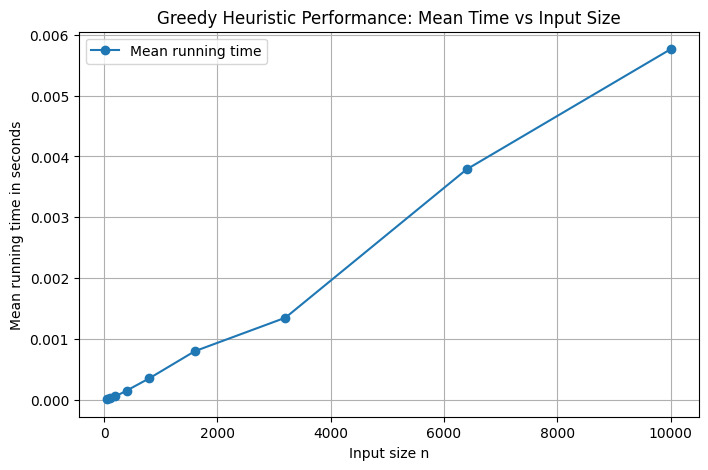

In [17]:
# Plot mean running time against input size

plt.figure(figsize=(8, 5))

plt.plot(
    performance_df["n"],
    performance_df["Mean Time"],
    marker="o",
    label="Mean running time"
)

plt.xlabel("Input size n")
plt.ylabel("Mean running time in seconds")
plt.title("Greedy Heuristic Performance: Mean Time vs Input Size")
plt.grid(True)
plt.legend()

plt.savefig("section6_mean_time_plot.png", dpi=300, bbox_inches="tight")
plt.show()

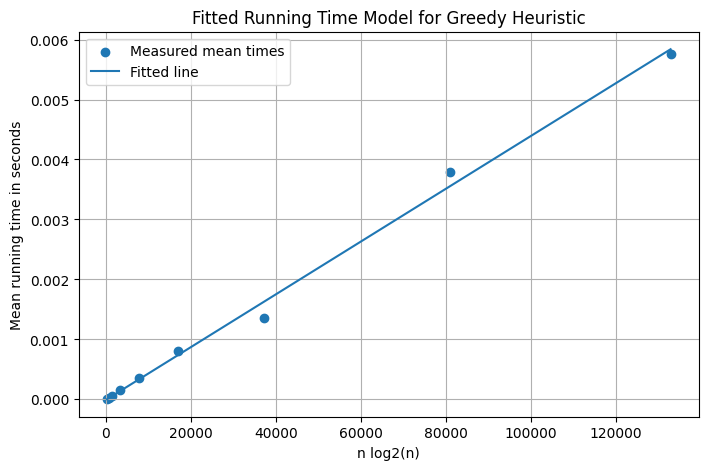

In [18]:
# Plot the fitted line using n log2(n)

plt.figure(figsize=(8, 5))

plt.scatter(
    x_values,
    y_values,
    label="Measured mean times"
)

fitted_y = slope * x_values + intercept

plt.plot(
    x_values,
    fitted_y,
    label="Fitted line"
)

plt.xlabel("n log2(n)")
plt.ylabel("Mean running time in seconds")
plt.title("Fitted Running Time Model for Greedy Heuristic")
plt.grid(True)
plt.legend()

plt.savefig("section6_fitted_line_plot.png", dpi=300, bbox_inches="tight")
plt.show()

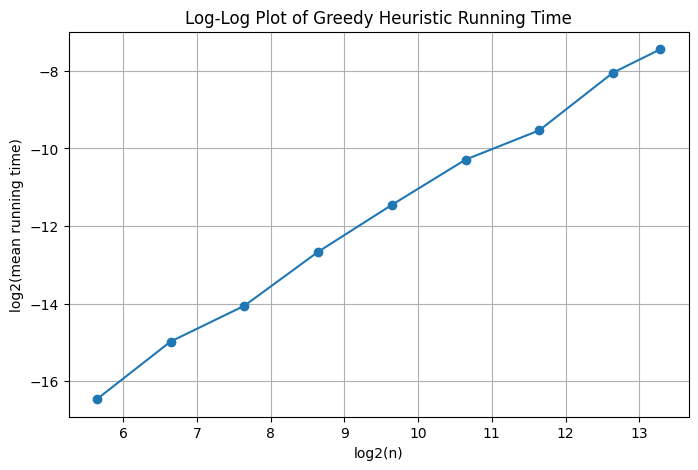

In [19]:
# Log-log plot to show growth pattern more clearly

plt.figure(figsize=(8, 5))

plt.plot(
    np.log2(performance_df["n"]),
    np.log2(performance_df["Mean Time"]),
    marker="o"
)

plt.xlabel("log2(n)")
plt.ylabel("log2(mean running time)")
plt.title("Log-Log Plot of Greedy Heuristic Running Time")
plt.grid(True)

plt.savefig("section6_log_log_plot.png", dpi=300, bbox_inches="tight")
plt.show()

## End of Section 6

The performance results were saved as:

`section6_performance_results.csv`

The generated plots were saved as:

- `section6_mean_time_plot.png`
- `section6_fitted_line_plot.png`
- `section6_log_log_plot.png`

These files can be included in the final report and final zip submission.

# Section 7: Experimental Analysis of Quality

In this section, we compare the solution quality of the greedy heuristic against the brute force optimal solution.

The brute force algorithm gives the optimal answer, but it can only be used for smaller input sizes.

The main quality measure is:

Quality Ratio = Greedy Sum / Brute Force Optimal Sum

A quality ratio close to 1 means the heuristic solution is close to optimal.

In [20]:
# Section 7 quality testing

random.seed(456)

# We keep n small enough so brute force can still find the optimal solution
quality_input_sizes = list(range(5, 19))

runs_per_size = 30

quality_results = []

for n in quality_input_sizes:

    for run in range(1, runs_per_size + 1):

        # Generate one random test case
        S, T = generate_subset_sum_instance(
            n=n,
            min_value=1,
            max_value=100,
            target_ratio=0.5,
            seed=(n * 1000 + run)
        )

        # Brute force gives the optimal solution
        brute_subset, brute_sum, brute_exact, brute_time = brute_force_subset_sum(S, T)

        # Greedy gives the heuristic solution
        greedy_subset, greedy_sum, greedy_exact, greedy_time = greedy_subset_sum(S, T)

        # Make sure the heuristic result is valid
        greedy_valid = greedy_sum <= T

        # Difference between optimal and heuristic result
        quality_gap = brute_sum - greedy_sum

        # Ratio close to 1 means greedy is close to optimal
        if brute_sum > 0:
            quality_ratio = greedy_sum / brute_sum
            percent_gap = (quality_gap / brute_sum) * 100
        else:
            quality_ratio = 1
            percent_gap = 0

        # True if greedy found the same sum as brute force
        greedy_optimal = (greedy_sum == brute_sum)

        quality_results.append({
            "n": n,
            "Run": run,
            "Target": T,
            "Input List": S,
            "Brute Force Sum": brute_sum,
            "Greedy Sum": greedy_sum,
            "Quality Gap": quality_gap,
            "Quality Ratio": quality_ratio,
            "Percent Gap": percent_gap,
            "Greedy Optimal": greedy_optimal,
            "Greedy Valid": greedy_valid,
            "Brute Force Time": brute_time,
            "Greedy Time": greedy_time
        })

quality_df = pd.DataFrame(quality_results)

quality_df

,n,Run,Target,Input List,Brute Force Sum,Greedy Sum,Quality Gap,Quality Ratio,Percent Gap,Greedy Optimal,Greedy Valid,Brute Force Time,Greedy Time
0,5,1,171,"[73, 38, 81, 55, 95]",168,168,0,1.000000,0.000000,True,True,0.000017,4.148000e-06
1,5,2,109,"[82, 33, 5, 1, 98]",104,104,0,1.000000,0.000000,True,True,0.000011,1.445000e-06
2,5,3,152,"[21, 99, 96, 52, 37]",151,151,0,1.000000,0.000000,True,True,0.000010,1.085999e-06
3,5,4,137,"[43, 36, 43, 78, 75]",122,121,1,0.991803,0.819672,False,True,0.000009,8.800016e-07
4,5,5,73,"[28, 25, 8, 28, 58]",66,66,0,1.000000,0.000000,True,True,0.000008,9.949999e-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...
415,18,26,491,"[25, 92, 8, 42, 84, 27, 16, 88, 18, 84, 96, 94...",491,491,0,1.000000,0.000000,True,True,0.003007,9.100999e-06
416,18,27,483,"[39, 29, 53, 72, 37, 86, 21, 66, 100, 84, 63, ...",483,475,8,0.983437,1.656315,False,True,0.007564,1.095700e-05
417,18,28,367,"[81, 1, 5, 19, 43, 20, 31, 13, 14, 95, 68, 7, ...",367,367,0,1.000000,0.000000,True,True,0.001256,7.489001e-06
418,18,29,536,"[54, 99, 26, 77, 15, 91, 89, 98, 60, 26, 97, 6...",536,536,0,1.000000,0.000000,True,True,0.003191,1.005600e-05


In [21]:
# Summarize the quality results by input size

quality_summary = quality_df.groupby("n").agg(
    Runs=("Run", "count"),
    Mean_Quality_Ratio=("Quality Ratio", "mean"),
    Minimum_Quality_Ratio=("Quality Ratio", "min"),
    Mean_Quality_Gap=("Quality Gap", "mean"),
    Mean_Percent_Gap=("Percent Gap", "mean"),
    Greedy_Optimal_Count=("Greedy Optimal", "sum"),
    Greedy_Valid_Count=("Greedy Valid", "sum")
).reset_index()

# Add the percentage of times greedy matched the optimal answer
quality_summary["Greedy Optimal Rate"] = quality_summary["Greedy_Optimal_Count"] / quality_summary["Runs"]

quality_summary

,n,Runs,Mean_Quality_Ratio,Minimum_Quality_Ratio,Mean_Quality_Gap,Mean_Percent_Gap,Greedy_Optimal_Count,Greedy_Valid_Count,Greedy Optimal Rate
0,5,30,0.979215,0.835366,2.766667,2.078484,22,30,0.733333
1,6,30,0.968230,0.864865,4.400000,3.176976,14,30,0.466667
2,7,30,0.974285,0.900000,4.200000,2.571497,10,30,0.333333
3,8,30,0.976580,0.933333,4.666667,2.342049,7,30,0.233333
4,9,30,0.974332,0.889632,6.400000,2.566840,9,30,0.300000
5,10,30,0.983375,0.932722,4.366667,1.662478,7,30,0.233333
6,11,30,0.980810,0.905292,5.733333,1.919025,6,30,0.200000
7,12,30,0.989742,0.948509,3.400000,1.025820,8,30,0.266667
8,13,30,0.989519,0.957983,3.566667,1.048068,4,30,0.133333
9,14,30,0.992797,0.968661,2.533333,0.720272,9,30,0.300000


In [22]:
# Save Section 7 quality results

quality_df.to_csv("section7_quality_results.csv", index=False)
quality_summary.to_csv("section7_quality_summary.csv", index=False)

print("Quality results saved as section7_quality_results.csv")
print("Quality summary saved as section7_quality_summary.csv")

Quality results saved as section7_quality_results.csv
Quality summary saved as section7_quality_summary.csv


In [23]:
# Create a clean table for the Google Docs report

quality_report_table = quality_summary[[
    "n",
    "Runs",
    "Mean_Quality_Ratio",
    "Minimum_Quality_Ratio",
    "Mean_Quality_Gap",
    "Mean_Percent_Gap",
    "Greedy Optimal Rate"
]].copy()

# Round values for a cleaner report table
quality_report_table["Mean_Quality_Ratio"] = quality_report_table["Mean_Quality_Ratio"].round(4)
quality_report_table["Minimum_Quality_Ratio"] = quality_report_table["Minimum_Quality_Ratio"].round(4)
quality_report_table["Mean_Quality_Gap"] = quality_report_table["Mean_Quality_Gap"].round(2)
quality_report_table["Mean_Percent_Gap"] = quality_report_table["Mean_Percent_Gap"].round(2)
quality_report_table["Greedy Optimal Rate"] = quality_report_table["Greedy Optimal Rate"].round(4)

quality_report_table

,n,Runs,Mean_Quality_Ratio,Minimum_Quality_Ratio,Mean_Quality_Gap,Mean_Percent_Gap,Greedy Optimal Rate
0,5,30,0.9792,0.8354,2.77,2.08,0.7333
1,6,30,0.9682,0.8649,4.40,3.18,0.4667
2,7,30,0.9743,0.9000,4.20,2.57,0.3333
3,8,30,0.9766,0.9333,4.67,2.34,0.2333
4,9,30,0.9743,0.8896,6.40,2.57,0.3000
5,10,30,0.9834,0.9327,4.37,1.66,0.2333
6,11,30,0.9808,0.9053,5.73,1.92,0.2000
7,12,30,0.9897,0.9485,3.40,1.03,0.2667
8,13,30,0.9895,0.9580,3.57,1.05,0.1333
9,14,30,0.9928,0.9687,2.53,0.72,0.3000


In [24]:
# Print the table in a copy-paste format for Google Docs

print(quality_report_table.to_markdown(index=False))

|   n |   Runs |   Mean_Quality_Ratio |   Minimum_Quality_Ratio |   Mean_Quality_Gap |   Mean_Percent_Gap |   Greedy Optimal Rate |
|----:|-------:|---------------------:|------------------------:|-------------------:|-------------------:|----------------------:|
|   5 |     30 |               0.9792 |                  0.8354 |               2.77 |               2.08 |                0.7333 |
|   6 |     30 |               0.9682 |                  0.8649 |               4.4  |               3.18 |                0.4667 |
|   7 |     30 |               0.9743 |                  0.9    |               4.2  |               2.57 |                0.3333 |
|   8 |     30 |               0.9766 |                  0.9333 |               4.67 |               2.34 |                0.2333 |
|   9 |     30 |               0.9743 |                  0.8896 |               6.4  |               2.57 |                0.3    |
|  10 |     30 |               0.9834 |                  0.9327 |           

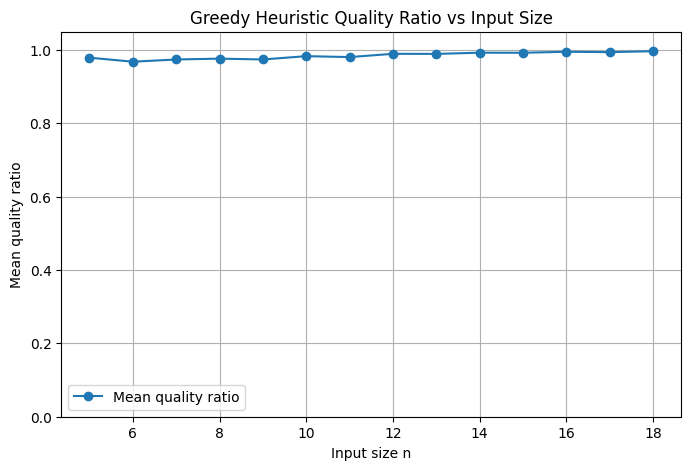

In [25]:
# Plot mean quality ratio against input size

plt.figure(figsize=(8, 5))

plt.plot(
    quality_summary["n"],
    quality_summary["Mean_Quality_Ratio"],
    marker="o",
    label="Mean quality ratio"
)

plt.xlabel("Input size n")
plt.ylabel("Mean quality ratio")
plt.title("Greedy Heuristic Quality Ratio vs Input Size")
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()

plt.savefig("section7_quality_ratio_plot.png", dpi=300, bbox_inches="tight")
plt.show()

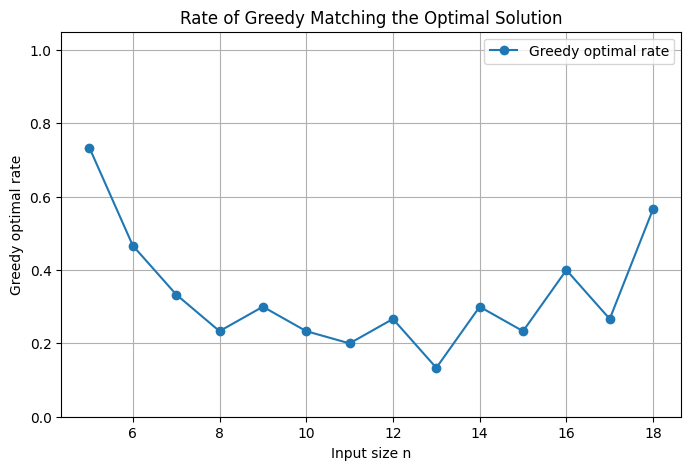

In [26]:
# Plot how often greedy matched the brute force optimal answer

plt.figure(figsize=(8, 5))

plt.plot(
    quality_summary["n"],
    quality_summary["Greedy Optimal Rate"],
    marker="o",
    label="Greedy optimal rate"
)

plt.xlabel("Input size n")
plt.ylabel("Greedy optimal rate")
plt.title("Rate of Greedy Matching the Optimal Solution")
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()

plt.savefig("section7_greedy_optimal_rate_plot.png", dpi=300, bbox_inches="tight")
plt.show()

## End of Section 7

The quality experiment results were saved as:

- `section7_quality_results.csv`
- `section7_quality_summary.csv`

The generated plots were saved as:

- `section7_quality_ratio_plot.png`
- `section7_greedy_optimal_rate_plot.png`

# Section 8: Experimental Analysis of Correctness / Functional Testing

In this section, we test whether the implementations behave correctly on known cases and edge cases.

The testing methods used are based on the lecture material:

- Functional testing
- Black-box testing
- Equivalence class testing
- White-box testing
- Statement coverage
- Decision coverage

The goal is to check for coding errors in the implementation.

In [27]:
# Section 8 functional testing test suite
# These tests use black-box testing, equivalence class testing,
# and white-box coverage ideas from the lecture slides.

functional_tests = [
    {
        "Test Name": "Target is zero",
        "S": [3, 5, 7],
        "T": 0,
        "Expected Brute Sum": 0,
        "Testing Method": "Black-box, boundary value",
        "Coverage Goal": "Empty subset / target zero case",
        "Description": "The empty subset should be valid when the target is zero."
    },
    {
        "Test Name": "Single element equals target",
        "S": [10],
        "T": 10,
        "Expected Brute Sum": 10,
        "Testing Method": "Black-box, equivalence class",
        "Coverage Goal": "Exact match with one element",
        "Description": "The only element exactly equals the target."
    },
    {
        "Test Name": "Single element below target",
        "S": [7],
        "T": 10,
        "Expected Brute Sum": 7,
        "Testing Method": "Black-box, equivalence class",
        "Coverage Goal": "Feasible non-exact single element",
        "Description": "The only element is below the target, so it should be selected."
    },
    {
        "Test Name": "Single element above target",
        "S": [12],
        "T": 10,
        "Expected Brute Sum": 0,
        "Testing Method": "Black-box, equivalence class",
        "Coverage Goal": "Single item skipped because it exceeds target",
        "Description": "The only element is too large, so the empty subset is best."
    },
    {
        "Test Name": "Exact subset exists",
        "S": [3, 5, 7, 10],
        "T": 15,
        "Expected Brute Sum": 15,
        "Testing Method": "Black-box, normal case",
        "Coverage Goal": "Exact subset exists",
        "Description": "A valid exact subset exists, such as [5, 10]."
    },
    {
        "Test Name": "No exact subset exists",
        "S": [2, 6, 8, 13],
        "T": 11,
        "Expected Brute Sum": 10,
        "Testing Method": "Black-box, equivalence class",
        "Coverage Goal": "No exact solution, best feasible sum returned",
        "Description": "No subset equals 11, but the best feasible sum is 10."
    },
    {
        "Test Name": "Multiple exact solutions",
        "S": [1, 3, 4, 5, 6],
        "T": 9,
        "Expected Brute Sum": 9,
        "Testing Method": "Black-box, equivalence class",
        "Coverage Goal": "Multiple correct optimal subsets",
        "Description": "Multiple subsets can reach the target, such as [3, 6] or [4, 5]."
    },
    {
        "Test Name": "Duplicate values",
        "S": [4, 4, 4, 6],
        "T": 8,
        "Expected Brute Sum": 8,
        "Testing Method": "Black-box, equivalence class",
        "Coverage Goal": "Repeated values treated as separate items",
        "Description": "The implementation should handle repeated values correctly."
    },
    {
        "Test Name": "All values larger than target",
        "S": [20, 30, 40],
        "T": 10,
        "Expected Brute Sum": 0,
        "Testing Method": "Black-box, boundary value",
        "Coverage Goal": "All items skipped / empty subset returned",
        "Description": "No value can be selected, so the empty subset is best."
    },
    {
        "Test Name": "Greedy misses optimal",
        "S": [10, 9, 6, 5],
        "T": 11,
        "Expected Brute Sum": 11,
        "Testing Method": "White-box, decision coverage",
        "Coverage Goal": "Greedy add/skip branches and non-optimal heuristic result",
        "Description": "Brute force finds [6, 5], while greedy selects [10]."
    },
    {
        "Test Name": "Greedy exact match",
        "S": [9, 8, 6, 5],
        "T": 14,
        "Expected Brute Sum": 14,
        "Testing Method": "White-box, statement coverage",
        "Coverage Goal": "Greedy reaches exact target branch",
        "Description": "Greedy selects [9, 5] and reaches the target exactly."
    },
    {
        "Test Name": "Greedy skip branch",
        "S": [15, 8, 7],
        "T": 15,
        "Expected Brute Sum": 15,
        "Testing Method": "White-box, decision coverage",
        "Coverage Goal": "Greedy selects one item and skips later items",
        "Description": "Greedy selects 15 and must skip later values because they exceed the target."
    }
]

In [28]:
# Run all functional tests

functional_results = []

for test_number, test in enumerate(functional_tests, start=1):
    S = test["S"]
    T = test["T"]

    # Run both implementations
    brute_subset, brute_sum, brute_exact, brute_time = brute_force_subset_sum(S, T)
    greedy_subset, greedy_sum, greedy_exact, greedy_time = greedy_subset_sum(S, T)

    # Brute force is exact, so it should match the expected optimal sum
    brute_pass = (brute_sum == test["Expected Brute Sum"])

    # Greedy is a heuristic, so we test validity instead of optimality
    greedy_valid = (greedy_sum <= T)
    greedy_pass = greedy_valid

    # This checks whether greedy happened to match the brute force optimum
    greedy_matches_optimal = (greedy_sum == brute_sum)

    # Overall pass means brute force is correct and greedy returns a valid result
    overall_pass = brute_pass and greedy_pass

    functional_results.append({
        "Test Number": test_number,
        "Test Name": test["Test Name"],
        "Testing Method": test["Testing Method"],
        "Coverage Goal": test["Coverage Goal"],
        "Input List": S,
        "Target": T,
        "Expected Brute Sum": test["Expected Brute Sum"],
        "Brute Force Subset": brute_subset,
        "Brute Force Sum": brute_sum,
        "Brute Force Pass": brute_pass,
        "Greedy Subset": greedy_subset,
        "Greedy Sum": greedy_sum,
        "Greedy Valid": greedy_valid,
        "Greedy Matches Optimal": greedy_matches_optimal,
        "Overall Pass": overall_pass,
        "Description": test["Description"]
    })

functional_df = pd.DataFrame(functional_results)

functional_df

,Test Number,Test Name,Testing Method,Coverage Goal,Input List,Target,Expected Brute Sum,Brute Force Subset,Brute Force Sum,Brute Force Pass,Greedy Subset,Greedy Sum,Greedy Valid,Greedy Matches Optimal,Overall Pass,Description
0,1,Target is zero,"Black-box, boundary value",Empty subset / target zero case,"[3, 5, 7]",0,0,[],0,True,[],0,True,True,True,The empty subset should be valid when the targ...
1,2,Single element equals target,"Black-box, equivalence class",Exact match with one element,[10],10,10,[10],10,True,[10],10,True,True,True,The only element exactly equals the target.
2,3,Single element below target,"Black-box, equivalence class",Feasible non-exact single element,[7],10,7,[7],7,True,[7],7,True,True,True,"The only element is below the target, so it sh..."
3,4,Single element above target,"Black-box, equivalence class",Single item skipped because it exceeds target,[12],10,0,[],0,True,[],0,True,True,True,"The only element is too large, so the empty su..."
4,5,Exact subset exists,"Black-box, normal case",Exact subset exists,"[3, 5, 7, 10]",15,15,"[5, 10]",15,True,"[10, 5]",15,True,True,True,"A valid exact subset exists, such as [5, 10]."
5,6,No exact subset exists,"Black-box, equivalence class","No exact solution, best feasible sum returned","[2, 6, 8, 13]",11,10,"[2, 8]",10,True,"[8, 2]",10,True,True,True,"No subset equals 11, but the best feasible sum..."
6,7,Multiple exact solutions,"Black-box, equivalence class",Multiple correct optimal subsets,"[1, 3, 4, 5, 6]",9,9,"[3, 6]",9,True,"[6, 3]",9,True,True,True,"Multiple subsets can reach the target, such as..."
7,8,Duplicate values,"Black-box, equivalence class",Repeated values treated as separate items,"[4, 4, 4, 6]",8,8,"[4, 4]",8,True,[6],6,True,False,True,The implementation should handle repeated valu...
8,9,All values larger than target,"Black-box, boundary value",All items skipped / empty subset returned,"[20, 30, 40]",10,0,[],0,True,[],0,True,True,True,"No value can be selected, so the empty subset ..."
9,10,Greedy misses optimal,"White-box, decision coverage",Greedy add/skip branches and non-optimal heuri...,"[10, 9, 6, 5]",11,11,"[6, 5]",11,True,[10],10,True,False,True,"Brute force finds [6, 5], while greedy selects..."


In [29]:
# Summary of functional test outcomes

total_tests = len(functional_df)
brute_pass_count = functional_df["Brute Force Pass"].sum()
greedy_valid_count = functional_df["Greedy Valid"].sum()
overall_pass_count = functional_df["Overall Pass"].sum()

print("Functional Testing Summary")
print("--------------------------")
print(f"Total tests: {total_tests}")
print(f"Brute force passed: {brute_pass_count}/{total_tests}")
print(f"Greedy valid results: {greedy_valid_count}/{total_tests}")
print(f"Overall passed: {overall_pass_count}/{total_tests}")

Functional Testing Summary
--------------------------
Total tests: 12
Brute force passed: 12/12
Greedy valid results: 12/12
Overall passed: 12/12


In [30]:
# Save Section 8 functional testing results

functional_df.to_csv("section8_functional_testing_results.csv", index=False)

print("Functional testing results saved as section8_functional_testing_results.csv")

Functional testing results saved as section8_functional_testing_results.csv


In [31]:
# Create a cleaner table for the Google Docs report

functional_report_table = functional_df[[
    "Test Number",
    "Test Name",
    "Testing Method",
    "Coverage Goal",
    "Input List",
    "Target",
    "Expected Brute Sum",
    "Brute Force Sum",
    "Brute Force Pass",
    "Greedy Sum",
    "Greedy Valid",
    "Overall Pass"
]].copy()

functional_report_table

,Test Number,Test Name,Testing Method,Coverage Goal,Input List,Target,Expected Brute Sum,Brute Force Sum,Brute Force Pass,Greedy Sum,Greedy Valid,Overall Pass
0,1,Target is zero,"Black-box, boundary value",Empty subset / target zero case,"[3, 5, 7]",0,0,0,True,0,True,True
1,2,Single element equals target,"Black-box, equivalence class",Exact match with one element,[10],10,10,10,True,10,True,True
2,3,Single element below target,"Black-box, equivalence class",Feasible non-exact single element,[7],10,7,7,True,7,True,True
3,4,Single element above target,"Black-box, equivalence class",Single item skipped because it exceeds target,[12],10,0,0,True,0,True,True
4,5,Exact subset exists,"Black-box, normal case",Exact subset exists,"[3, 5, 7, 10]",15,15,15,True,15,True,True
5,6,No exact subset exists,"Black-box, equivalence class","No exact solution, best feasible sum returned","[2, 6, 8, 13]",11,10,10,True,10,True,True
6,7,Multiple exact solutions,"Black-box, equivalence class",Multiple correct optimal subsets,"[1, 3, 4, 5, 6]",9,9,9,True,9,True,True
7,8,Duplicate values,"Black-box, equivalence class",Repeated values treated as separate items,"[4, 4, 4, 6]",8,8,8,True,6,True,True
8,9,All values larger than target,"Black-box, boundary value",All items skipped / empty subset returned,"[20, 30, 40]",10,0,0,True,0,True,True
9,10,Greedy misses optimal,"White-box, decision coverage",Greedy add/skip branches and non-optimal heuri...,"[10, 9, 6, 5]",11,11,11,True,10,True,True


In [32]:
# Print the table in copy-paste format for Google Docs

print(functional_report_table.to_markdown(index=False))

|   Test Number | Test Name                     | Testing Method                | Coverage Goal                                             | Input List      |   Target |   Expected Brute Sum |   Brute Force Sum | Brute Force Pass   |   Greedy Sum | Greedy Valid   | Overall Pass   |
|--------------:|:------------------------------|:------------------------------|:----------------------------------------------------------|:----------------|---------:|---------------------:|------------------:|:-------------------|-------------:|:---------------|:---------------|
|             1 | Target is zero                | Black-box, boundary value     | Empty subset / target zero case                           | [3, 5, 7]       |        0 |                    0 |                 0 | True               |            0 | True           | True           |
|             2 | Single element equals target  | Black-box, equivalence class  | Exact match with one element                              | [10]  

## End of Section 8

The functional testing results were saved as:

`section8_functional_testing_results.csv`

These tests check whether the implementations behave correctly on known cases and edge cases.

The test suite used methods from the lecture slides:

- Functional testing
- Black-box testing
- Equivalence class testing
- White-box testing
- Statement coverage
- Decision coverage